# Stroke Risk Prediction: Full Machine Learning Pipeline and Dashboard

This notebook performs a comprehensive analysis and builds a predictive model for stroke risk.

### Workflow:
1. **Data Acquisition**: Loading the healthcare dataset.
2. **Exploratory Data Analysis (EDA)**: Visualizing distributions, correlations, and patterns.
3. **Statistical Analysis**: Checking for significant relationships.
4. **Data Preprocessing**: Handling missing values, encoding categorical variables, and scaling.
5. **Feature Engineering**: Creating or selecting relevant features.
6. **Model Development**: Training multiple classifiers (Random Forest, XGBoost, SVM, etc.).
7. **Model Evaluation & Comparison**: Analyzing performance metrics and ROC curves.
8. **Deployment**: Creating a Gradio dashboard for real-time predictions.

## 1. **Data Acquisition**:
Loading the Stroke dataset from the kaggle.

Link: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

# Load the dataset
file_path = '/content/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(file_path)

In [ ]:
# Initial overview
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [ ]:
print("\nData Types:\n", df.dtypes)


Data Types:
 id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [ ]:
# Stroke rate by categorical features
print("\n--- Stroke Rate by Categorical Features ---")
for col in cat_features:
    rate = df.groupby(col)['stroke'].mean().sort_values(ascending=False)
    print(f"\nStroke rate for {col}:\n{rate}")


--- Stroke Rate by Categorical Features ---

Stroke rate for gender:
gender
Male      0.051064
Female    0.047094
Other     0.000000
Name: stroke, dtype: float64

Stroke rate for hypertension:
hypertension
1    0.132530
0    0.039679
Name: stroke, dtype: float64

Stroke rate for heart_disease:
heart_disease
1    0.170290
0    0.041787
Name: stroke, dtype: float64

Stroke rate for ever_married:
ever_married
Yes    0.065613
No     0.016505
Name: stroke, dtype: float64

Stroke rate for work_type:
work_type
Self-employed    0.079365
Private          0.050940
Govt_job         0.050228
children         0.002911
Never_worked     0.000000
Name: stroke, dtype: float64

Stroke rate for Residence_type:
Residence_type
Urban    0.052003
Rural    0.045346
Name: stroke, dtype: float64

Stroke rate for smoking_status:
smoking_status
formerly smoked    0.079096
smokes             0.053232
never smoked       0.047569
Unknown            0.030440
Name: stroke, dtype: float64


## 2. Exploratory Data Analysis (EDA)
We will analyze the distribution of features and their relationship with the target variable `stroke`.

/tmp/ipykernel_35649/4172055965.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='viridis')


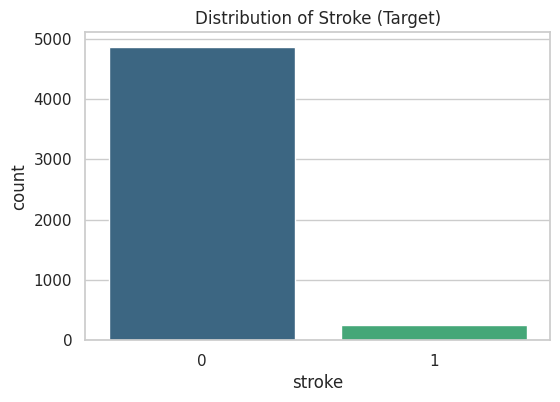

In [ ]:
# Set plotting style
sns.set(style='whitegrid')

# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette='viridis')
plt.title('Distribution of Stroke (Target)')
plt.show()



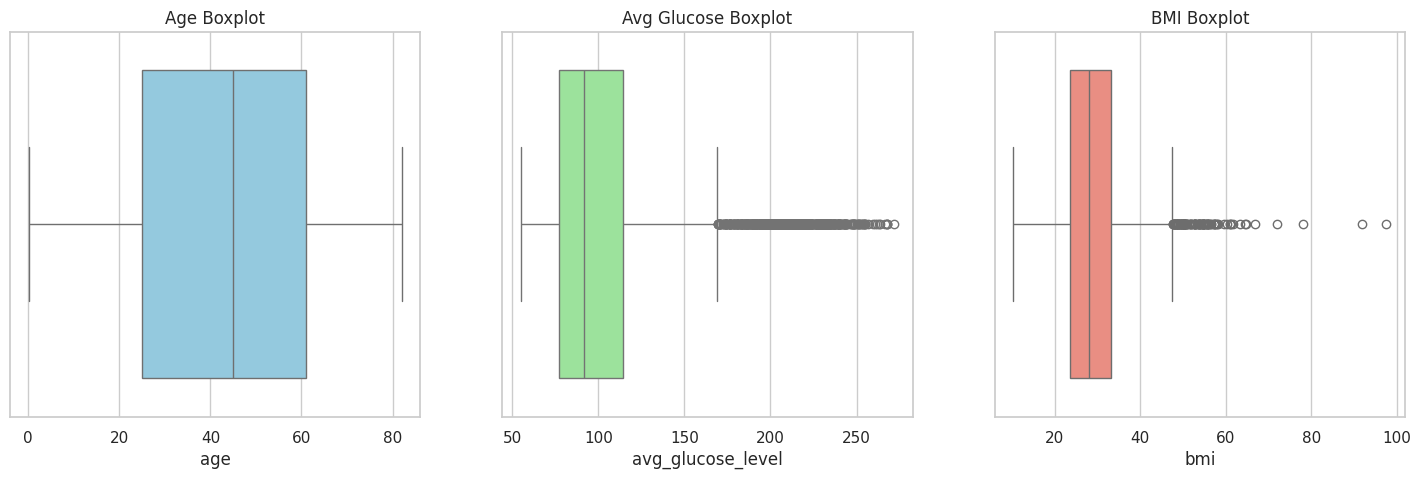

In [ ]:
# Boxplots for Numerical Outlier Detection
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x=df['age'], ax=axes[0], color='skyblue').set_title('Age Boxplot')
sns.boxplot(x=df['avg_glucose_level'], ax=axes[1], color='lightgreen').set_title('Avg Glucose Boxplot')
sns.boxplot(x=df['bmi'].dropna(), ax=axes[2], color='salmon').set_title('BMI Boxplot')
plt.show()

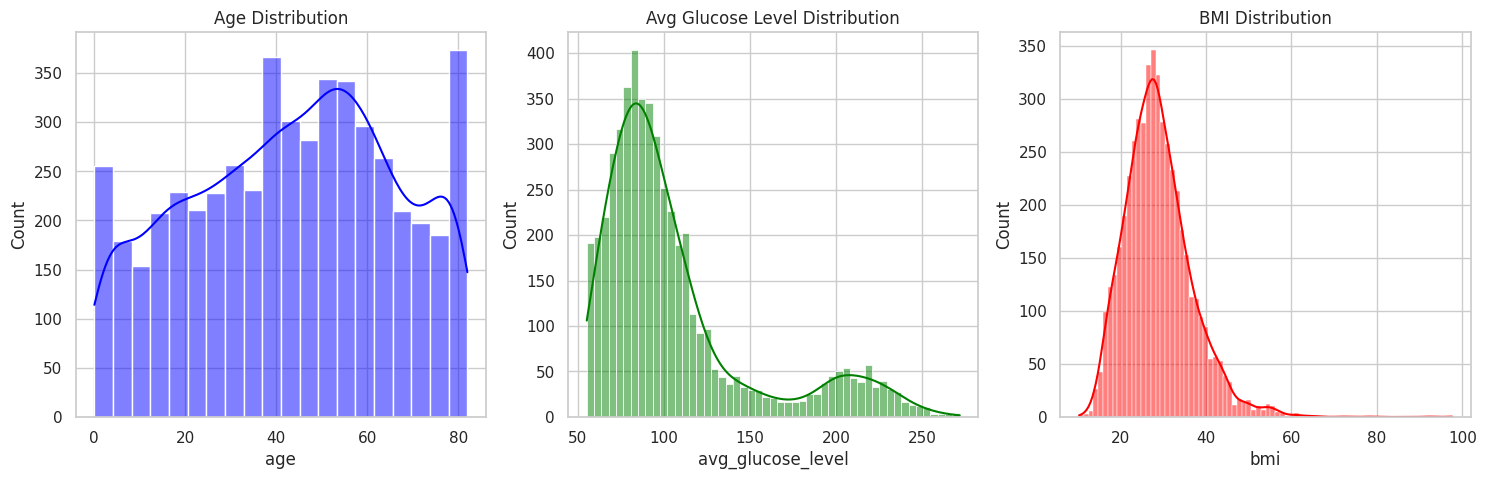

In [ ]:
# Numerical Features Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['age'], kde=True, ax=axes[0], color='blue').set_title('Age Distribution')
sns.histplot(df['avg_glucose_level'], kde=True, ax=axes[1], color='green').set_title('Avg Glucose Level Distribution')
sns.histplot(df['bmi'].dropna(), kde=True, ax=axes[2], color='red').set_title('BMI Distribution')
plt.show()

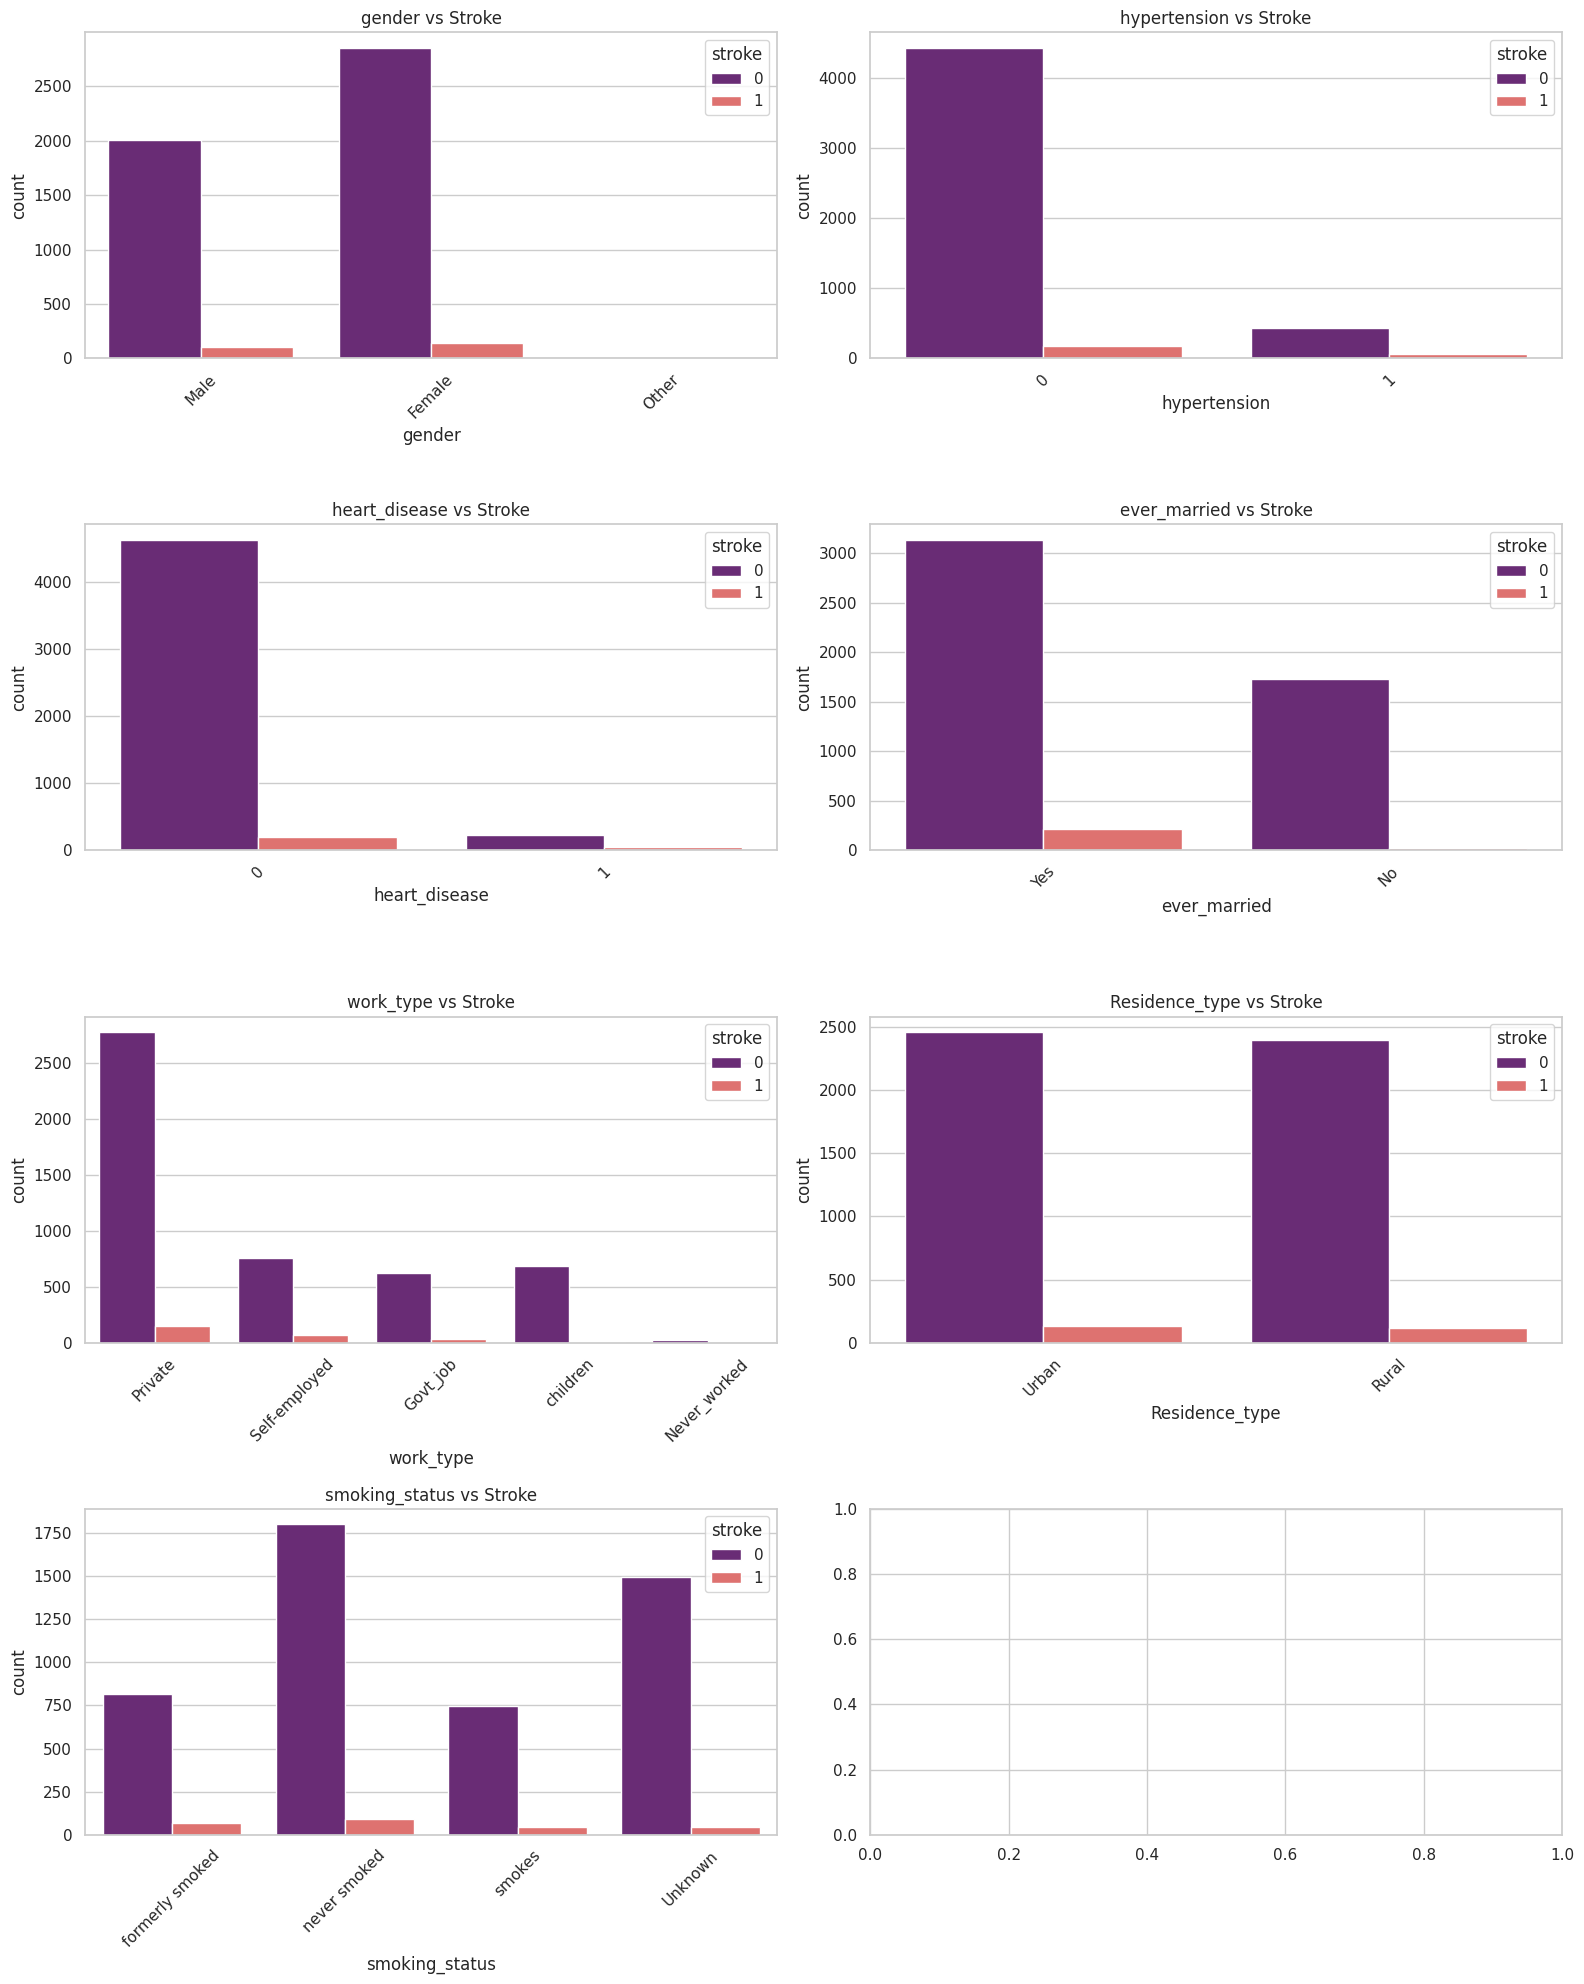

In [ ]:
# Categorical Features vs Stroke
cat_features = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue='stroke', data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'{col} vs Stroke')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

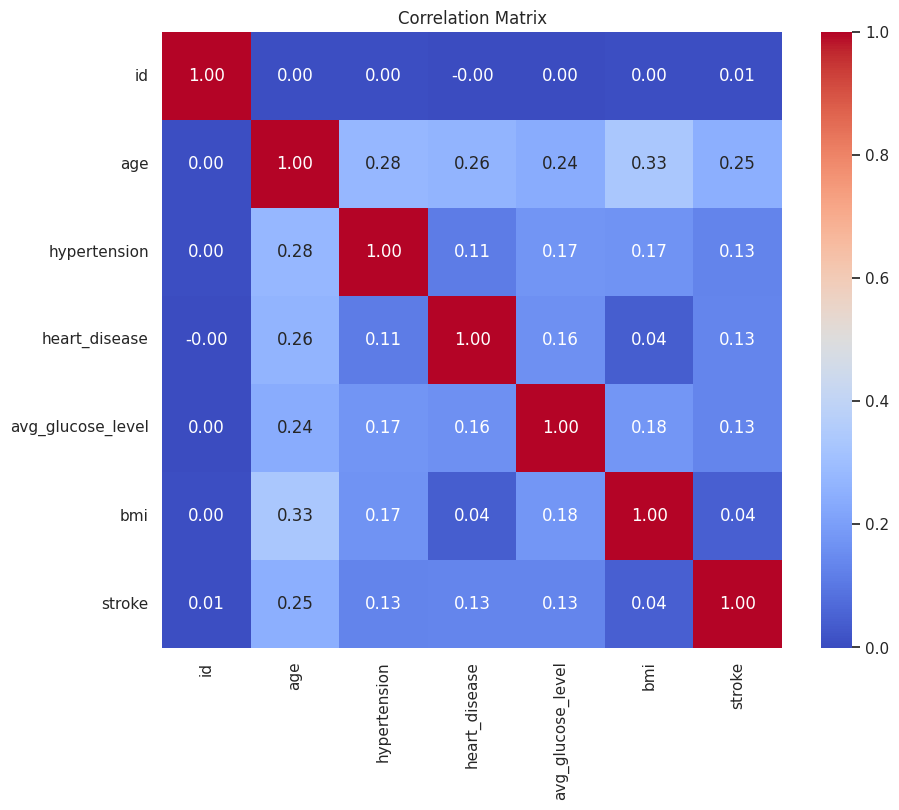

In [ ]:
# Correlation Heatmap (Numeric Only)
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# T-test for Age and Stroke
stroke_age = df[df['stroke'] == 1]['age']
no_stroke_age = df[df['stroke'] == 0]['age']
t_stat, p_val = stats.ttest_ind(stroke_age, no_stroke_age)
print(f"T-test for Age vs Stroke: p-value = {p_val:.4f}")

T-test for Age vs Stroke: p-value = 0.0000


## 3. Data Preprocessing & Feature Engineering
In this step, we will:
1.  **Handle Missing Values**: Impute `bmi` using the median.
2.  **Feature Encoding**: Convert categorical text into numerical values.
3.  **Data Splitting**: Separate training and testing sets.
4.  **Handling Imbalance**: Use SMOTE to balance the minority stroke class.
5.  **Scaling**: Normalize numerical features.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

In [ ]:
# Copy for preprocessing
prep_df = df.copy()

In [ ]:
# 1. Impute BMI
prep_df['bmi'] = prep_df['bmi'].fillna(prep_df['bmi'].median())

In [ ]:
# 2. Encoding
le = LabelEncoder()
cat_cols = prep_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    prep_df[col] = le.fit_transform(prep_df[col])

# Remove ID
X = prep_df.drop(['id', 'stroke'], axis=1)
y = prep_df['stroke']

In [ ]:
# 3. Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# 4. Handle Class Imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
# 5. Scaling
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

print(f'Training set size after SMOTE: {X_train_res.shape}')
print(f'Test set size: {X_test.shape}')

Training set size after SMOTE: (7778, 10)
Test set size: (1022, 10)


## 4. Model Development and Comparison
We will train Random Forest, Logistic Regression, and XGBoost to compare their performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:59:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


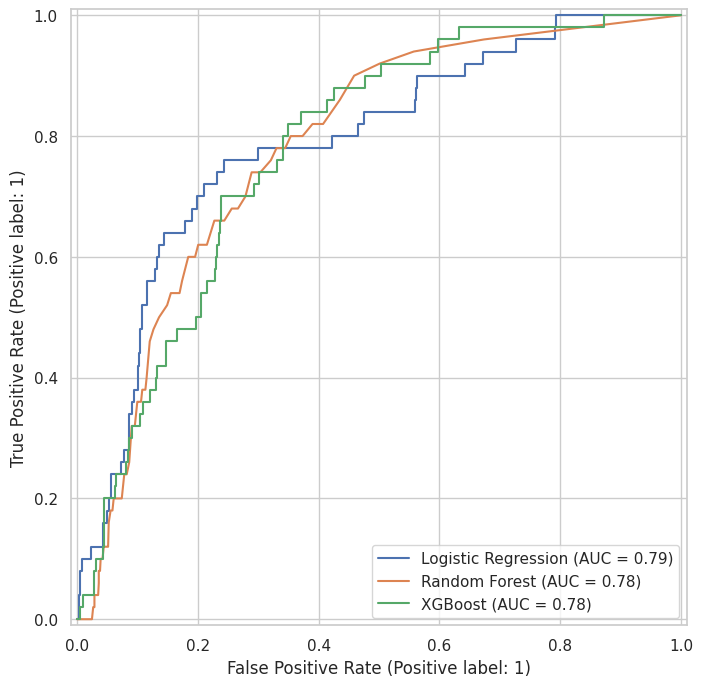

In [ ]:
results = {}
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'Accuracy': acc, 'ROC-AUC': auc}

    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

In [ ]:
res_df = pd.DataFrame(results).T
display(res_df)

,Accuracy,ROC-AUC
Logistic Regression,0.784736,0.786626
Random Forest,0.903131,0.781759
XGBoost,0.907045,0.777058



==================== Logistic Regression Evaluation ====================
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       972
           1       0.15      0.72      0.25        50

    accuracy                           0.78      1022
   macro avg       0.57      0.75      0.56      1022
weighted avg       0.94      0.78      0.84      1022



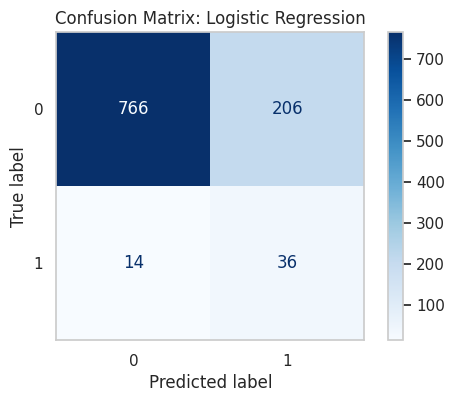


==================== Random Forest Evaluation ====================
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.14      0.20      0.17        50

    accuracy                           0.90      1022
   macro avg       0.55      0.57      0.56      1022
weighted avg       0.92      0.90      0.91      1022



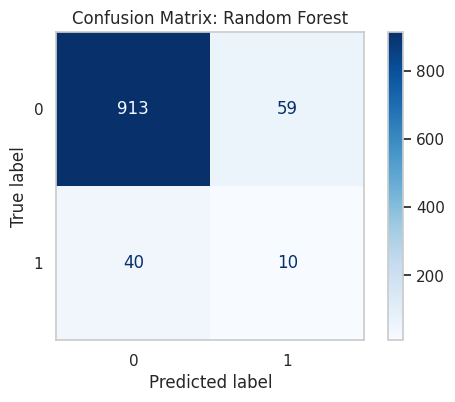


==================== XGBoost Evaluation ====================
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.15      0.20      0.17        50

    accuracy                           0.91      1022
   macro avg       0.56      0.57      0.56      1022
weighted avg       0.92      0.91      0.91      1022



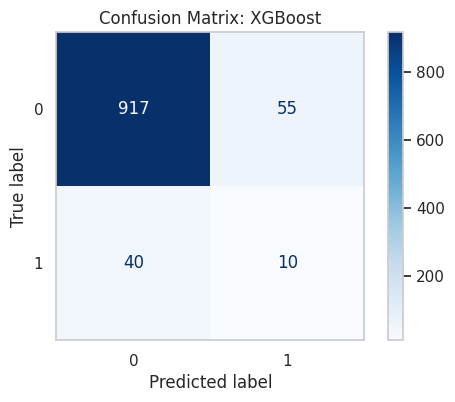

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Individual Model Evaluation
for name, model in models.items():
    print(f"\n{'='*20} {name} Evaluation {'='*20}")

    # Predictions
    y_pred = model.predict(X_test)

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    fig, ax = plt.subplots(figsize=(6, 4))
    disp.plot(cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix: {name}')
    plt.grid(False)
    plt.show()

## 5. **Deployement and Prediction**:
Creating a Gradio dashboard for real-time predictions.

In [ ]:
import gradio as gr
import joblib

In [ ]:
# Test cases for the model
sample_tests = [
    {
        'name': 'High Risk Profile',
        'data': ['Male', 75, 1, 1, 'Yes', 'Private', 'Urban', 220.5, 33.0, 'formerly smoked']
    },
    {
        'name': 'Low Risk Profile',
        'data': ['Female', 22, 0, 0, 'No', 'Private', 'Rural', 85.0, 22.5, 'never smoked']
    }
]

print("--- Model Testing Results ---")
for test in sample_tests:
    result = predict_stroke(*test['data'])
    print(f"{test['name']}: {result}")

--- Model Testing Results ---
High Risk Profile: Estimated Stroke Risk Probability: 30.06%
Low Risk Profile: Estimated Stroke Risk Probability: 7.16%


In [ ]:
# Save the best model and scaler for the application
best_model_name = res_df['ROC-AUC'].idxmax()
best_model = models[best_model_name]
joblib.dump(best_model, 'best_stroke_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:

def predict_stroke(gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status):
    # Create input DataFrame matching training feature structure
    input_data = pd.DataFrame([[gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status]],
                             columns=['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status'])

    # Manual mapping to match LabelEncoder logic used during preprocessing
    input_data['gender'] = 1 if gender == 'Male' else (0 if gender == 'Female' else 2)
    input_data['ever_married'] = 1 if ever_married == 'Yes' else 0
    input_data['Residence_type'] = 1 if Residence_type == 'Urban' else 0

    work_map = {'Private': 2, 'Self-employed': 3, 'Govt_job': 0, 'children': 4, 'Never_worked': 1}
    input_data['work_type'] = work_map.get(work_type, 2)

    smoke_map = {'formerly smoked': 1, 'never smoked': 2, 'smokes': 3, 'Unknown': 0}
    input_data['smoking_status'] = smoke_map.get(smoking_status, 0)

    # Apply scaling and predict probability
    input_scaled = scaler.transform(input_data)
    probability = best_model.predict_proba(input_scaled)[0][1]

    return f"Estimated Stroke Risk Probability: {probability:.2%}"

In [ ]:
# Define Gradio Dashboard
interface = gr.Interface(
    fn=predict_stroke,
    inputs=[
        gr.Dropdown(['Male', 'Female', 'Other'], label='Gender'),
        gr.Slider(0, 100, value=50, label='Age'),
        gr.Radio([0, 1], label='Hypertension (0: No, 1: Yes)'),
        gr.Radio([0, 1], label='Heart Disease (0: No, 1: Yes)'),
        gr.Dropdown(['Yes', 'No'], label='Ever Married'),
        gr.Dropdown(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'], label='Work Type'),
        gr.Dropdown(['Urban', 'Rural'], label='Residence Type'),
        gr.Number(label='Avg Glucose Level', value=100),
        gr.Number(label='BMI', value=28.0),
        gr.Dropdown(['formerly smoked', 'never smoked', 'smokes', 'Unknown'], label='Smoking Status')
    ],
    outputs="text",
    title="Stroke Risk Prediction Dashboard",
    description="Input health details to estimate stroke risk using the optimized Logistic Regression model."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://09915ce2970f545184.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
